# Notebook 01 — The Geometric Engine
## Building the "lens" of our digital telescope · Paper §3.1–3.2

---
### The big picture (read this first)

Imagine a highway camera. A truck 20 metres away fills thousands of pixels; a car
500 metres away is a tiny smudge of maybe 4×8 pixels. Normal object detectors are
overwhelmed by the big nearby objects and miss the small faraway ones.

**Telescope's idea:** before the detector looks at the image, *warp* the picture like a
magnifying glass — stretch the faraway region so the distant car becomes big and
detectable, and squeeze the nearby region (we already see the truck fine).

To do that magnification **and be able to undo it later**, we need a precise piece of
mathematics: a function that maps every pixel position to a new position, plus its exact
inverse. That mathematical "lens" is what we build in this notebook. Everything else in
the project (warping images, detecting objects, drawing boxes) sits on top of it.

> **Where this fits in the whole project**
> - **NB 01 (you are here):** grind the lens — the warp function Φ and its inverse Φ⁻¹.
> - NB 02: mount the lens — actually warp images with it.
> - NB 03: calibrate — tell the detector how the lens is set.
> - NB 04: read through the lens — detect objects and un-warp the results.
> - NB 05: assemble the full instrument and train it.
> - NB 06: test whether it really sees farther.

---
### The four pieces of maths we implement here

Each symbol is explained in plain words
when we reach it. All pixel positions are rescaled to the range −1…1 (so the image
centre is 0,0 and the corners are ±1). This is just a convenient unit system.

**1. The Poincaré projection** $h(x;o)$ — the raw "magnify around a point" operation:
$$h(x;o) = o + \frac{\tanh(\alpha r)}{r}(x - o), \quad r = \|x - o\|$$

**2. The foveated transform** $\Phi(x)$ — blends magnification with "leave it alone",
so only the region of interest is warped:
$$\Phi(x) = (1 - w(r))\,x + w(r)\,h(x;o), \quad w(r) = \left(1 - \min\!\left(\tfrac{r}{R},1\right)\right)^p$$

**3. The inverse** $\Phi^{-1}$ — undoes the warp, computed step-by-step with Newton-Raphson:
$$x^{(k+1)} = x^{(k)} + \eta\bigl(y - \Phi(x^{(k)})\bigr)$$

**4. The Jacobian** $J_\Phi$ — measures how much the warp stretches space at each point
(needed later to warp bounding-box sizes correctly).

The two knobs $\alpha$ (how strong the magnification is) and $p$ (how sharply it fades
out) are fixed to the paper's values $\alpha = 2.0$, $p = 2.0$. The "where" and "how big"
of the magnification — the centre $o$ and radius $R$ — will later be *learned* by the network.

In [35]:
import sys, pathlib
# Add the project root to sys.path so 'import telescope' works
# from notebooks/  →  parent dir  →  telescope/
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import torch
import torch.nn as nn
import warnings
from torch import Tensor
import matplotlib.pyplot as plt
import numpy as np   # visualisation only — never inside forward()

torch.set_default_dtype(torch.float32)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {DEVICE}')

PyTorch 2.12.0+cu130 | device: cpu


---
## 1 · The Poincaré projection $h(x; o)$ — the raw magnifier

**In plain words:** this function takes a point and pushes it toward (or pulls it away
from) a chosen centre $o$. Points very close to the centre barely move; the further out
a point starts, the more it gets pulled inward. The net visual effect is that the area
*around* the centre appears stretched out — magnified — because the pixels that used to
be packed near the centre are now spread over a wider area.

The name comes from the *Poincaré disk*, a classic model of "hyperbolic" (curved) space
used in geometry. We borrow its maths because it gives smooth, well-behaved magnification
that never blows up to infinity.

We `import` these functions from the `telescope` package rather than redefining them —
the same code that runs here also runs in training, so there is a single source of truth.

```
★ Insight ─────────────────────────────────────
  • tanh(αr)/r → α as r→0: right at the centre the formula would be
    0/0, but its limit is a clean multiply-by-α. The EPS clamp in the
    code is what safely handles that 0/0 point on a computer.
  • For points far from the centre, tanh(αr)/r → 0, meaning they get
    pulled almost all the way to o. The blend weight w(r) (next section)
    is what stops the periphery from collapsing.
  • Straight lines through o stay straight — the warp is purely radial
    (it changes distances from o, never angles around o).
─────────────────────────────────────────────────
```

In [36]:
from telescope.geometry import (
    EPS,
    poincare_projection,
    blend_weight,
    hyperbolic_foveated_transform,
    compute_jacobian,
    HyperbolicInverseNR,
    hyperbolic_inverse,
    validate_inversion,
)
from telescope.box import euclidean_to_riemannian_box, riemannian_to_euclidean_box
from telescope.estimator import FoveationEstimator

print('telescope package imported successfully.')

telescope package imported successfully.


---
## 2 · The foveated transform $\Phi(x)$ — magnify here, leave the rest alone

The raw magnifier from §1 would distort the *entire* image. We don't want that — we only
want to magnify a chosen region (where the distant objects are) and leave the rest
untouched.

$\Phi$ achieves this with a **blend**. At every point it mixes two options:
- the magnified position $h(x)$ (from §1), and
- the original, untouched position $x$.

The mixing ratio is the weight $w(r)$:
- **Near the centre** ($r$ small): $w \approx 1$ → use the full magnification.
- **Past the radius $R$** ($r \geq R$): $w = 0$ → leave the pixel exactly where it was.

So $R$ defines the size of the "magnifying glass", and $\Phi$ smoothly fades from
"fully magnified" at the centre to "no change" at the edge of that glass. The word
*foveation* comes from the **fovea** — the high-resolution centre of your eye's retina.
Your eyes do exactly this: sharp detail in the centre of your gaze, blurry at the edges.

This $\Phi$ is the single most important function in the project — every later step either
applies it, inverts it, or measures it.

In [37]:
def hyperbolic_foveated_transform(
    x: Tensor,
    o: Tensor,
    R: Tensor,
    alpha: float = 2.0,
    p: float = 2.0,
) -> Tensor:
    """Phi(x) = (1 - w(r)) * x + w(r) * h(x; o).  Eq.(2).

    Behaviour:
        r << R  →  Phi ≈ h(x)  (hyperbolic magnification near o)
        r >= R  →  Phi = x     (identity outside Poincaré radius)

    Args:
        x     : (..., 2) normalized image coordinates
        o     : (2,) foveation center (learned by FFN)
        R     : scalar tensor, radial scale (learned by FFN)
        alpha : hyperbolic contraction strength  [paper: 2.0]
        p     : blending exponent               [paper: 2.0]
    Returns:
        (..., 2) transformed coordinates
    """
    d = x - o                                               # (..., 2)
    r = torch.norm(d, dim=-1, keepdim=True).clamp(min=EPS) # (..., 1)
    h = poincare_projection(x, o, alpha)                    # (..., 2)
    w = blend_weight(r, R, p)                               # (..., 1)
    return (1.0 - w) * x + w * h                           # (..., 2)

---
## 3 · The Jacobian $J_\Phi(x)$ — "how much does the warp stretch here?"

**In plain words:** the Jacobian is a little 2×2 table of numbers, computed at each point,
that says how a tiny step in the original image turns into a (bigger or smaller, possibly
rotated) step in the warped image. Think of it as the *local zoom factor* of the lens.

Why do we care? Because later we don't just warp pixel *positions* — we warp **bounding
boxes**, which have a width and a height. To know how wide a box becomes after warping, we
need the local stretch factor exactly at the box's location. That is what $J_\Phi$ gives us.

We could ask PyTorch to compute this automatically, but we derive it **by hand** for speed
and accuracy. The result has a neat structure: a uniform scaling part plus a "stretch
extra along the radial direction" part.

$$J_\Phi(x) = \underbrace{(1 + f(r))}_{\text{scale in every direction}}\, I_2 \;+\; \underbrace{\frac{f'(r)}{r}}_{\text{extra stretch outward}} (d \otimes d)$$

The check in §6 confirms our hand-derived formula matches PyTorch's automatic answer to
within rounding error — a good habit whenever you replace autograd with a manual derivative.

```
★ Insight ─────────────────────────────────────
  • The two eigenvalues of this matrix are the stretch factors along
    and across the radial direction:
       λ_tangential = 1 + f(r)        (sideways, around the centre)
       λ_radial     = 1 + f(r) + r·f'(r)   (outward, away from centre)
  • A magnified region has eigenvalues > 1 (a small box becomes large).
  • Because the matrix is "scaled identity + rank-1", it can be inverted
    in O(1) with the Sherman–Morrison formula — handy at inference time.
─────────────────────────────────────────────────
```

In [38]:
def compute_jacobian(
    x: Tensor,
    o: Tensor,
    R: Tensor,
    alpha: float = 2.0,
    p: float = 2.0,
) -> Tensor:
    """Analytical Jacobian J_Phi(x) for each point in x.

    J = (1 + f(r)) * I2  +  (f'(r)/r) * (d outer d)
    where f(r) = w(r) * (s(r) - 1),  s(r) = tanh(alpha*r)/r.

    Args:
        x : (..., 2)
        o : (2,)
        R : scalar tensor
    Returns:
        (..., 2, 2) Jacobian matrices
    """
    d = x - o                                                    # (..., 2)
    r = torch.norm(d, dim=-1, keepdim=True).clamp(min=EPS)      # (..., 1)

    # ── s(r) = tanh(αr)/r  and  s'(r) = α·sech²(αr)/r − s/r ──
    ar       = alpha * r                                         # (..., 1)
    tanh_ar  = torch.tanh(ar)                                    # (..., 1)
    s        = tanh_ar / r                                       # (..., 1)
    sech2_ar = 1.0 - tanh_ar.pow(2)                             # (..., 1)
    ds_dr    = alpha * sech2_ar / r - s / r                     # (..., 1)

    # ── w(r) = (1 − clamp(r/R, 0,1))^p  and  dw/dr ──
    r_over_R    = (r / R.clamp(min=EPS)).clamp(max=1.0)
    one_minus   = 1.0 - r_over_R                                # (..., 1) in [0,1]
    w           = one_minus ** p
    inside_R    = r < R
    # Safe: replace 0^(p-1) with 1 in the masked-off region
    om_safe     = torch.where(inside_R, one_minus, torch.ones_like(one_minus))
    dw_dr       = torch.where(
        inside_R,
        -p / R.clamp(min=EPS) * om_safe.pow(p - 1),
        torch.zeros_like(r)
    )

    # ── f(r) and f'(r) ──
    f     = w * (s - 1.0)                                       # (..., 1)
    df_dr = dw_dr * (s - 1.0) + w * ds_dr                      # (..., 1)

    # ── J = (1+f)*I2 + (f'/r)*(d⊗d) ──
    batch_shape = d.shape[:-1]                                   # (...)
    I2      = torch.eye(2, dtype=x.dtype, device=x.device)
    I2      = I2.expand(*batch_shape, 2, 2).clone()             # (..., 2, 2)
    d_outer = d.unsqueeze(-1) * d.unsqueeze(-2)                 # (..., 2, 2)

    a = (1.0 + f).unsqueeze(-1)                                 # (..., 1, 1)
    b = (df_dr / r).unsqueeze(-1)                               # (..., 1, 1)

    return a * I2 + b * d_outer                                 # (..., 2, 2)

---
## 4 · The inverse $\Phi^{-1}$ — undoing the warp

**Why we need it:** the detector will find objects in the *warped* image and report their
positions there. But we want their positions in the *original* image. So we must run the
lens backwards: given a warped position $y$, find the original position $x$ such that
$\Phi(x) = y$.

**The catch:** $\Phi$ has no tidy "backwards formula" you can write down. So instead we
*solve* for the answer by repeated guessing — the **Newton-Raphson** method:

1. Guess that the answer is just $y$ itself.
2. Apply $\Phi$ to the guess and see how far off we are (the "residual").
3. Nudge the guess to reduce the error.
4. Repeat ~8 times until the error is microscopic (below 1e-6).

It is like adjusting a focus knob: look, see it's blurry, turn a bit, look again — converging
fast on sharp focus. We will *plot* this convergence in §10 so you can watch the error shrink.

### A subtle but important engineering decision

When this runs inside a neural network, gradients must flow back through it during training.
We have two ways to make that happen:

| Approach | What it costs | Quality |
|---|---|---|
| Let PyTorch record all 8 guessing steps | 8× the memory | gradients degrade over the steps |
| **Tell PyTorch the answer's derivative directly** | almost nothing | exact |

We use the second, via a custom `torch.autograd.Function`. The trick (the **Implicit
Function Theorem**) says: if $y = \Phi(x^*)$, then the derivative of the inverse is simply
the inverse of the Jacobian we built in §3. So we don't need to remember *how* we found the
answer — only the answer itself — and we get an exact gradient from one small 2×2 solve.
This is the same idea behind "Deep Equilibrium Models".

```
★ Insight ─────────────────────────────────────
  • The forward guessing loop runs inside torch.no_grad(), so it uses
    constant memory no matter how many iterations it takes.
  • The backward pass is EXACT even though the forward is approximate —
    the theorem only needs that Φ(x*) = y, not how we got there.
  • The clamp(-1.5, 1.5) keeps early guesses from flying off the image
    while the method is still converging.
─────────────────────────────────────────────────
```

In [39]:
class HyperbolicInverseNR(torch.autograd.Function):
    """Differentiable Phi^{-1} via Newton-Raphson + implicit differentiation backward."""

    @staticmethod
    def forward(
        ctx,
        y: Tensor,
        o: Tensor,
        R: Tensor,
        alpha: float,
        p: float,
        eta: float,
        max_iter: int,
        tol: float,
    ) -> Tensor:
        """NR: x^{k+1} = x^k + eta * (y - Phi(x^k)), x^0 = y.

        All NR iterations run inside torch.no_grad() — no graph is built.
        """
        with torch.no_grad():
            x = y.clone()
            for _ in range(max_iter):
                residual = y - hyperbolic_foveated_transform(x, o, R, alpha, p)
                x = (x + eta * residual).clamp(-1.5, 1.5)  # stability clamp
                if residual.abs().max().item() < tol:
                    break
            else:
                max_res = residual.abs().max().item()
                warnings.warn(
                    f"NR did not converge in {max_iter} iters. "
                    f"Max residual: {max_res:.2e} (tol={tol:.2e})",
                    RuntimeWarning,
                )

        ctx.save_for_backward(x, o, R)
        ctx.alpha  = alpha
        ctx.p      = p
        return x

    @staticmethod
    def backward(ctx, grad_output: Tensor):
        """Implicit Function Theorem: dL/dy = J_Phi(x*)^{-T} @ dL/dx*."""
        x_star, o, R = ctx.saved_tensors

        J = compute_jacobian(x_star, o, R, ctx.alpha, ctx.p)   # (..., 2, 2)

        # Solve J^T @ grad_y = grad_output  (torch.linalg.solve solves A @ x = b)
        grad_y = torch.linalg.solve(
            J.mT,                                              # (..., 2, 2)
            grad_output.unsqueeze(-1),                         # (..., 2, 1)
        ).squeeze(-1)                                          # (..., 2)

        # (y, o, R, alpha, p, eta, max_iter, tol)
        return grad_y, None, None, None, None, None, None, None


def hyperbolic_inverse(
    y: Tensor,
    o: Tensor,
    R: Tensor,
    alpha: float = 2.0,
    p: float = 2.0,
    eta: float = 0.5,
    max_iter: int = 50,
    tol: float = 1e-6,
) -> Tensor:
    """Functional interface to HyperbolicInverseNR.apply(...)."""
    return HyperbolicInverseNR.apply(y, o, R, alpha, p, eta, max_iter, tol)

---
## 5 · Validation: Round-trip error $\|P - \Phi^{-1}(\Phi(P))\|$

In [40]:
def validate_inversion(
    points: Tensor,
    o: Tensor,
    R: Tensor,
    alpha: float = 2.0,
    p: float = 2.0,
    warn_tol: float = 1e-5,
) -> dict:
    """Validate Phi -> Phi^{-1} round-trip for a tensor of points.

    Emits UserWarning and prints a report if any error > warn_tol.

    Args:
        points   : (N, 2) or (2,)  input points in [-1, 1]^2
        o        : (2,) foveation center
        R        : scalar tensor
        alpha, p : transform hyperparameters
        warn_tol : error threshold that triggers warning (default 1e-5)

    Returns:
        dict(max_error, mean_error, errors_per_point, all_passed)
    """
    if points.dim() == 1:
        points = points.unsqueeze(0)

    with torch.no_grad():
        phi_p         = hyperbolic_foveated_transform(points, o, R, alpha, p)
        reconstructed = hyperbolic_inverse(phi_p, o, R, alpha, p)
        errors        = torch.norm(points - reconstructed, dim=-1)  # (N,)

    max_err  = errors.max().item()
    mean_err = errors.mean().item()
    passed   = max_err < warn_tol

    SEP = '=' * 58
    print(SEP)
    print('INVERSION VALIDATION REPORT')
    print(SEP)
    print(f'  Points      : {points.shape[0]}')
    print(f'  Params      : o={[round(v,3) for v in o.tolist()]}  '
          f'R={R.item():.3f}  alpha={alpha}  p={p}')
    print(f'  Max error   : {max_err:.2e}')
    print(f'  Mean error  : {mean_err:.2e}')
    print(f'  Tolerance   : {warn_tol:.2e}')

    if passed:
        print('  Status      : PASS')
    else:
        bad = (errors >= warn_tol).nonzero(as_tuple=True)[0]
        print(f'  Status      : WARNING — {len(bad)} point(s) exceed tolerance')
        print(f'  Bad indices : {bad.tolist()}')
        print(f'  Bad errors  : {errors[bad].tolist()}')
        warnings.warn(
            f'Inversion error {max_err:.2e} > tolerance {warn_tol:.2e} '
            f'at {len(bad)} point(s).',
            UserWarning,
        )

    print(SEP)
    return dict(max_error=max_err, mean_error=mean_err,
                errors_per_point=errors, all_passed=passed)

---
## 6 · Sanity checks & unit tests

In [41]:
# ── Test 1: L'Hôpital limit at r→0 ──────────────────────────────────────────
def test_poincare_limit():
    o = torch.tensor([0.1, -0.2])
    x = o + 1e-7  # very close to o
    h = poincare_projection(x.unsqueeze(0), o, alpha=2.0)
    assert torch.allclose(h.squeeze(), x, atol=1e-5), 'L Hopital limit failed'
    print('PASS  test_poincare_limit')


# ── Test 2: identity outside radius R ────────────────────────────────────────
def test_identity_outside_R():
    o = torch.zeros(2)
    R = torch.tensor(0.5)
    # point exactly at r = R: w(R) = 0  =>  Phi(x) = x
    x = (R * torch.tensor([1.0, 0.0])).unsqueeze(0)
    phi_x = hyperbolic_foveated_transform(x, o, R)
    assert torch.allclose(phi_x, x, atol=1e-6), 'Identity at r=R failed'
    print('PASS  test_identity_outside_R')


# ── Test 3: single point round-trip ──────────────────────────────────────────
def test_round_trip_single():
    o = torch.tensor([0.0, 0.0])
    R = torch.tensor(0.6)
    result = validate_inversion(torch.tensor([[0.1, 0.2]]), o, R)
    assert result['all_passed'], f"max_error={result['max_error']:.2e}"
    print('PASS  test_round_trip_single')


# ── Test 4: batch of 200 random points ───────────────────────────────────────
def test_round_trip_batch():
    torch.manual_seed(42)
    o = torch.tensor([0.05, -0.1])
    R = torch.tensor(0.7)
    pts = (torch.rand(200, 2) * 2 - 1) * 0.85  # avoid extreme boundary
    result = validate_inversion(pts, o, R)
    assert result['all_passed']
    print('PASS  test_round_trip_batch')


# ── Test 5: analytical Jacobian vs torch.func.jacrev ─────────────────────────
def test_jacobian_correctness():
    from torch.func import jacrev, vmap
    torch.manual_seed(0)
    x = torch.rand(6, 2) * 0.6 - 0.3
    o = torch.tensor([0.0, 0.0])
    R = torch.tensor(0.7)

    J_analytic = compute_jacobian(x, o, R)

    def phi_single(xi):
        return hyperbolic_foveated_transform(xi.unsqueeze(0), o, R).squeeze(0)

    J_auto = vmap(jacrev(phi_single))(x)

    max_diff = (J_analytic - J_auto).abs().max().item()
    assert max_diff < 1e-5, f'Jacobian mismatch: {max_diff:.2e}'
    print(f'PASS  test_jacobian_correctness  (max_diff={max_diff:.2e})')


# ── Test 6: gradcheck on forward transform ────────────────────────────────────
def test_gradcheck_forward():
    torch.manual_seed(0)
    x = (torch.rand(3, 2, dtype=torch.float64) * 0.6 - 0.3).requires_grad_(True)
    o = torch.tensor([0.05, -0.05], dtype=torch.float64)
    R = torch.tensor(0.7, dtype=torch.float64)

    ok = torch.autograd.gradcheck(
        lambda x_: hyperbolic_foveated_transform(x_, o, R),
        (x,), eps=1e-6, atol=1e-4, rtol=1e-3,
    )
    assert ok
    print('PASS  test_gradcheck_forward')


# ── Test 7: gradcheck on NR inverse (implicit backward) ───────────────────────
def test_gradcheck_inverse():
    """gradcheck verifies that our IFT backward matches finite-differences."""
    torch.manual_seed(0)
    o = torch.tensor([0.0, 0.0], dtype=torch.float64)
    R = torch.tensor(0.7, dtype=torch.float64)

    x_orig = torch.rand(3, 2, dtype=torch.float64) * 0.4 - 0.2
    # Start from valid Phi(x) to ensure NR converges
    y = hyperbolic_foveated_transform(x_orig, o, R).detach().requires_grad_(True)

    ok = torch.autograd.gradcheck(
        lambda y_: hyperbolic_inverse(y_, o, R),
        (y,), eps=1e-6, atol=1e-4, rtol=1e-3,
    )
    assert ok
    print('PASS  test_gradcheck_inverse')

In [42]:
print('Running all sanity checks...\n')
test_poincare_limit()
test_identity_outside_R()
test_round_trip_single()
test_round_trip_batch()
test_jacobian_correctness()
test_gradcheck_forward()
test_gradcheck_inverse()
print('\nAll tests passed.')

Running all sanity checks...

PASS  test_poincare_limit
PASS  test_identity_outside_R
INVERSION VALIDATION REPORT
  Points      : 1
  Params      : o=[0.0, 0.0]  R=0.600  alpha=2.0  p=2.0
  Max error   : 5.66e-07
  Mean error  : 5.66e-07
  Tolerance   : 1.00e-05
  Status      : PASS
PASS  test_round_trip_single
INVERSION VALIDATION REPORT
  Points      : 200
  Params      : o=[0.05, -0.1]  R=0.700  alpha=2.0  p=2.0
  Max error   : 8.45e-07
  Mean error  : 1.11e-07
  Tolerance   : 1.00e-05
  Status      : PASS
PASS  test_round_trip_batch
PASS  test_jacobian_correctness  (max_diff=1.19e-07)
PASS  test_gradcheck_forward
PASS  test_gradcheck_inverse

All tests passed.


---
## 7 · Seeing the warp — how to read the plots below

We now apply $\Phi$ to a regular grid of points and draw the result. This is the clearest
way to *see* what the lens does. Each plot below has three panels:

- **Left — "Original grid":** an evenly-spaced grid of dots. The red dot is the foveation
  centre $o$; the dashed red circle is the radius $R$ (the edge of the magnifying glass).
- **Middle — "Transformed grid $\Phi(x)$":** the same dots after warping. Watch how the
  dots **spread apart near the centre** (that region is magnified) and **bunch together
  near the circle** (that region is compressed to make room). Outside the circle the dots
  are unchanged.
- **Right — "Displacement magnitude":** a heat-map of how far each point moved. Bright =
  moved a lot, dark = barely moved. You should see a bright ring of motion inside the
  radius and pure black (zero motion) outside it — visual proof that the warp is contained.

We draw it twice: once centred, once off-centre, to show the magnifying glass can be aimed
anywhere (which is exactly what the network will learn to do — aim it at distant traffic).

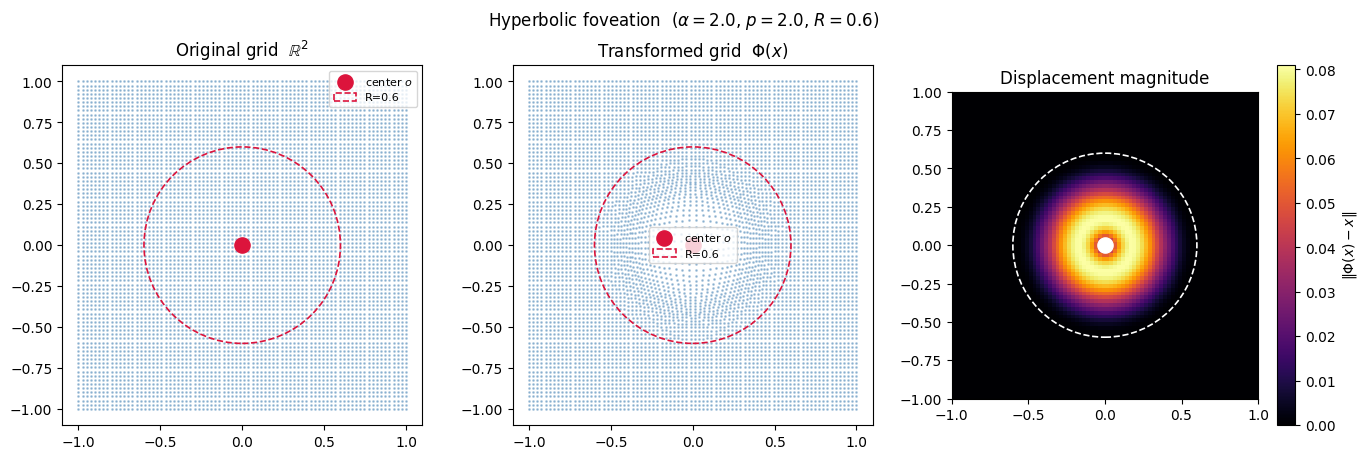

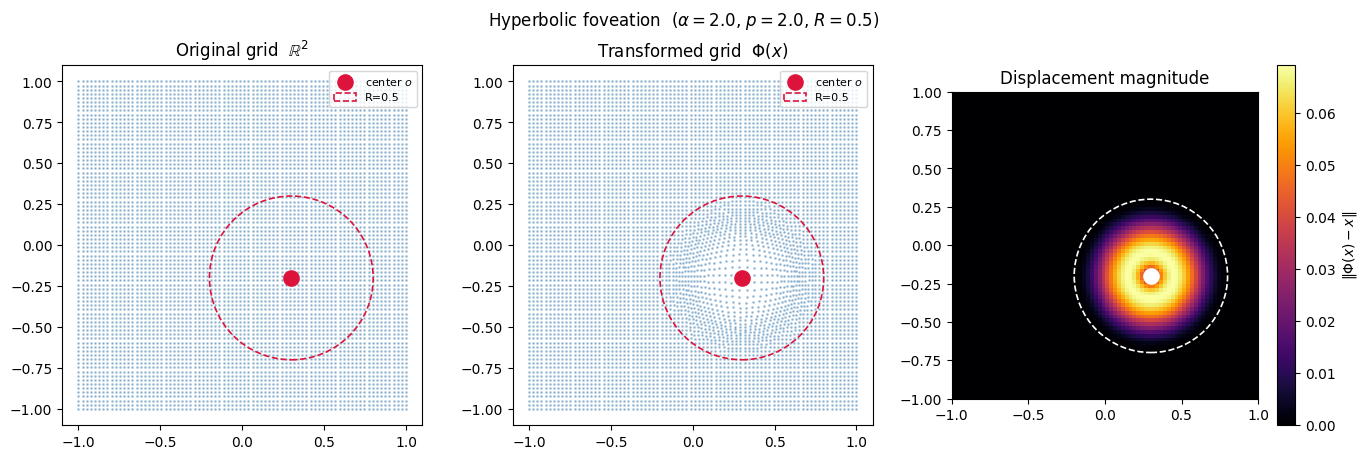

In [43]:
def visualize_foveation(o_list, R_val, alpha=2.0, p=2.0, res=80):
    """Plot original grid, transformed grid, and displacement magnitude."""
    lin   = torch.linspace(-1, 1, res)
    gx, gy = torch.meshgrid(lin, lin, indexing='xy')
    grid  = torch.stack([gx.flatten(), gy.flatten()], dim=-1)   # (N, 2)

    o = torch.tensor(o_list)
    R = torch.tensor(R_val)

    with torch.no_grad():
        grid_t = hyperbolic_foveated_transform(grid, o, R, alpha, p)

    displ = torch.norm(grid_t - grid, dim=-1).view(res, res).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

    for ax, pts, title in zip(
        axes[:2],
        [grid, grid_t],
        ['Original grid  $\\mathbb{R}^2$', 'Transformed grid  $\\Phi(x)$'],
    ):
        ax.scatter(pts[:, 0].numpy(), pts[:, 1].numpy(), s=1, c='steelblue', alpha=0.4)
        ax.scatter(*o_list, c='crimson', s=120, zorder=5, label='center $o$')
        ax.add_patch(plt.Circle(o_list, R_val, fill=False, color='crimson',
                                linestyle='--', linewidth=1.2, label=f'R={R_val}'))
        ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
        ax.set_aspect('equal'); ax.set_title(title); ax.legend(fontsize=8)

    im = axes[2].imshow(displ, extent=[-1, 1, -1, 1], origin='lower',
                         cmap='inferno', vmin=0)
    axes[2].scatter(*o_list, c='white', s=120, zorder=5)
    axes[2].add_patch(plt.Circle(o_list, R_val, fill=False, color='white',
                                  linestyle='--', linewidth=1.2))
    plt.colorbar(im, ax=axes[2], label='$\\|\\Phi(x)-x\\|$')
    axes[2].set_title('Displacement magnitude')

    fig.suptitle(f'Hyperbolic foveation  ($\\alpha={alpha}$, $p={p}$, $R={R_val}$)',
                  fontsize=12)
    plt.tight_layout()
    plt.show()


visualize_foveation(o_list=[0.0, 0.0], R_val=0.6)
visualize_foveation(o_list=[0.3, -0.2], R_val=0.5)  # off-center foveation

---
## 8 · Warping bounding boxes, not just points (Paper §3.2)

So far we have warped *points*. But a detector outputs **boxes** — each with a centre, a
width, and a height. When you warp an image, a box drawn on it should warp too: a small box
on a distant car should become a big box on the now-magnified car.

Here is the problem this section solves. A normal bounding box is "axis-aligned" — its sides
are perfectly horizontal and vertical. But after a non-linear warp, a rectangle's sides bend
slightly, so a plain rectangle no longer fits. The paper's solution is to describe the warped
box not by a width and height, but by:

- **where its centre lands** after warping: $\Phi(c)$, and
- **two "tangent vectors"** $t_x, t_y$ — arrows showing which way and how far the box's width
  and height directions get stretched, obtained by multiplying the box's size by the
  Jacobian $J_\Phi$ from §3.

We only need to store the *lengths* of those arrows ($\|t_x\|$, $\|t_y\|$), because their
directions are fully determined by the warp parameters. So a Euclidean box
$[c_x, c_y, w, h]$ becomes a "Riemannian" box $[\Phi(c_x), \Phi(c_y), \|t_x\|, \|t_y\|]$.

**Why this matters for the next notebooks:** the detector (NB 04) will predict boxes in this
Riemannian form, directly in the warped image. The `encode`/`decode` pair below — and its
round-trip test — is what lets us convert freely between the normal box world and the warped
box world, which is the backbone of the whole training loss.

$$b' = [\Phi_x(c),\; \Phi_y(c),\; \|t_x\|,\; \|t_y\|], \qquad
t_x = J_\Phi(c)\,[w, 0]^\top, \quad t_y = J_\Phi(c)\,[0, h]^\top$$

In [44]:
def euclidean_to_riemannian_box(
    boxes: Tensor,
    o: Tensor,
    R: Tensor,
    alpha: float = 2.0,
    p: float = 2.0,
) -> Tensor:
    """Encode Euclidean boxes [cx, cy, w, h] -> Riemannian [Phi(c), ||tx||, ||ty||].

    Args:
        boxes : (N, 4) in [cx, cy, w, h] format, normalized coords
    Returns:
        (N, 4) Riemannian boxes
    """
    c = boxes[:, :2]                                          # (N, 2) centers
    w = boxes[:, 2:3]                                         # (N, 1)
    h = boxes[:, 3:4]                                         # (N, 1)

    phi_c = hyperbolic_foveated_transform(c, o, R, alpha, p)  # (N, 2)
    J     = compute_jacobian(c, o, R, alpha, p)               # (N, 2, 2)

    # cat along dim=-1: (N,1) || (N,1) -> (N,2)  [stack would give (N,1,2)]
    e_x = torch.cat([w, torch.zeros_like(w)], dim=-1)         # (N, 2)
    e_y = torch.cat([torch.zeros_like(h), h], dim=-1)         # (N, 2)

    # (N,2,2) @ (N,2,1) -> (N,2,1) -> (N,2)
    t_x = (J @ e_x.unsqueeze(-1)).squeeze(-1)
    t_y = (J @ e_y.unsqueeze(-1)).squeeze(-1)

    tx_norm = torch.norm(t_x, dim=-1, keepdim=True)           # (N, 1)
    ty_norm = torch.norm(t_y, dim=-1, keepdim=True)           # (N, 1)

    return torch.cat([phi_c, tx_norm, ty_norm], dim=-1)       # (N, 4)


# ── Smoke test ───────────────────────────────────────────────────────────────
torch.manual_seed(7)
boxes_eu = torch.rand(5, 4) * 0.4 - 0.2
boxes_eu[:, 2:] = boxes_eu[:, 2:].abs() + 0.05   # ensure w, h > 0
o_test = torch.tensor([0.0, 0.0])
R_test = torch.tensor(0.7)

boxes_ri = euclidean_to_riemannian_box(boxes_eu, o_test, R_test)
assert boxes_ri.shape == (5, 4), f"Unexpected shape: {boxes_ri.shape}"
print('Euclidean boxes (cx, cy, w, h):')
print(boxes_eu.round(decimals=4))
print('\nRiemannian boxes (Phi_x, Phi_y, ||tx||, ||ty||):')
print(boxes_ri.round(decimals=4))
print('\nSMOKE TEST PASSED')

Euclidean boxes (cx, cy, w, h):
tensor([[ 0.0140, -0.1205,  0.1137,  0.1128],
        [-0.1069, -0.0300,  0.1672,  0.1019],
        [-0.0539,  0.1405,  0.1920,  0.0704],
        [-0.0853, -0.1175,  0.0720,  0.1063],
        [ 0.0882, -0.1708,  0.2380,  0.2069]])

Riemannian boxes (Phi_x, Phi_y, ||tx||, ||ty||):
tensor([[ 0.0232, -0.1997,  0.1880,  0.1506],
        [-0.1801, -0.0505,  0.2351,  0.1696],
        [-0.0851,  0.2221,  0.2949,  0.0879],
        [-0.1359, -0.1873,  0.1061,  0.1445],
        [ 0.1302, -0.2523,  0.3318,  0.2347]])

SMOKE TEST PASSED


---
## 9 · Riemannian → Euclidean decode (loss-time path)

At loss computation time, the detection head predicts $b'$ in Riemannian space.
We recover the Euclidean box by:
1. Inverting the center: $c = \Phi^{-1}(\Phi(c))$ — i.e. apply $\Phi^{-1}$ to the predicted $\Phi(c)$
2. Recovering $w, h$ from the tangent norms via the **inverse Jacobian**:
   $[w, 0]^\top = J_\Phi(c)^{-1} \cdot t_x$

This decode is fully differentiable through `HyperbolicInverseNR` and `compute_jacobian`.

In [45]:
def riemannian_to_euclidean_box(
    boxes_ri: Tensor,
    o: Tensor,
    R: Tensor,
    alpha: float = 2.0,
    p: float = 2.0,
) -> Tensor:
    """Decode Riemannian boxes [Phi(c), ||tx||, ||ty||] -> Euclidean [cx, cy, w, h].

    Inverse of euclidean_to_riemannian_box.
    Used at loss time to convert predicted Riemannian boxes to Euclidean space.

    Args:
        boxes_ri : (N, 4) Riemannian boxes  [phi_cx, phi_cy, tx_norm, ty_norm]
    Returns:
        (N, 4) Euclidean boxes  [cx, cy, w, h]
    """
    phi_c   = boxes_ri[:, :2]                                  # (N, 2)
    tx_norm = boxes_ri[:, 2:3]                                 # (N, 1)
    ty_norm = boxes_ri[:, 3:4]                                 # (N, 1)

    # Step 1: recover center via Phi^{-1}
    c = hyperbolic_inverse(phi_c, o, R, alpha, p)              # (N, 2)

    # Step 2: recover w, h via J_Phi(c)^{-1}
    #   t_x = J @ [w, 0]^T  =>  [w, 0]^T = J^{-1} @ t_x
    #   ||t_x|| = tx_norm, and t_x is aligned with J's first column scaled by w.
    #   Full inversion: build unit tangent vectors and scale by norm.
    J    = compute_jacobian(c, o, R, alpha, p)                 # (N, 2, 2)
    J_inv = torch.linalg.inv(J)                               # (N, 2, 2)

    # J @ [w, 0]^T = col_0(J) * w  =>  [w, 0]^T = J^{-1} @ (col_0(J) * w)
    # But we only have ||t_x||, not t_x itself.
    # Recover: w = ||J^{-1} @ t_x_unit|| * tx_norm, where t_x_unit = J[:,0] / ||J[:,0]||
    # Equivalently: w = tx_norm / ||J[:,0]||  and  h = ty_norm / ||J[:,1]||
    # Proof: t_x = J @ [w,0]^T = J[:,0]*w  =>  ||t_x|| = ||J[:,0]|| * w  (w > 0)
    col0_norm = torch.norm(J[:, :, 0], dim=-1, keepdim=True)  # (N, 1) = ||J[:,0]||
    col1_norm = torch.norm(J[:, :, 1], dim=-1, keepdim=True)  # (N, 1) = ||J[:,1]||

    w = tx_norm / col0_norm.clamp(min=EPS)                    # (N, 1)
    h = ty_norm / col1_norm.clamp(min=EPS)                    # (N, 1)

    return torch.cat([c, w, h], dim=-1)                       # (N, 4)


# ── Round-trip test: Euclidean -> Riemannian -> Euclidean ────────────────────
torch.manual_seed(42)
boxes_eu_orig = torch.rand(10, 4) * 0.5 - 0.25
boxes_eu_orig[:, 2:] = boxes_eu_orig[:, 2:].abs() + 0.05

o_rt = torch.tensor([0.0, 0.0])
R_rt = torch.tensor(0.6)

boxes_ri_enc = euclidean_to_riemannian_box(boxes_eu_orig, o_rt, R_rt)
boxes_eu_dec = riemannian_to_euclidean_box(boxes_ri_enc, o_rt, R_rt)

box_err = (boxes_eu_orig - boxes_eu_dec).abs()
print(f'Box round-trip max error  : {box_err.max().item():.2e}')
print(f'Box round-trip mean error : {box_err.mean().item():.2e}')
assert box_err.max().item() < 1e-4, 'Box round-trip failed'
print('PASS  box round-trip')

Box round-trip max error  : 6.85e-07
Box round-trip mean error : 1.14e-07
PASS  box round-trip


---
## 10 · Watching the inverse converge — how to read the plot

Remember the "focus knob" analogy from §4: the inverse $\Phi^{-1}$ is found by repeated
guessing. This plot shows that guessing in action.

- **The x-axis** is the guess number (iteration 1, 2, 3, …).
- **The y-axis** is the remaining error — how far the current guess still is from the true
  answer. Note it is on a **log scale**, so each gridline down means 10× more accurate.
- **Each coloured line** is a different step size $\eta$ (how big a nudge we take each
  guess). The dashed grey line marks our target accuracy of 1e-6.

What you want to see: every line **plunging downward** and crossing the target line within
a handful of iterations. A straight line on a log plot means the error shrinks by a constant
factor each step — fast, reliable convergence. The paper reports ~8 iterations is enough;
the printout below confirms how many our settings actually need.

This matters for deployment: fewer iterations = faster inference. We will revisit this in
NB 05 when we discuss running the model in real time.

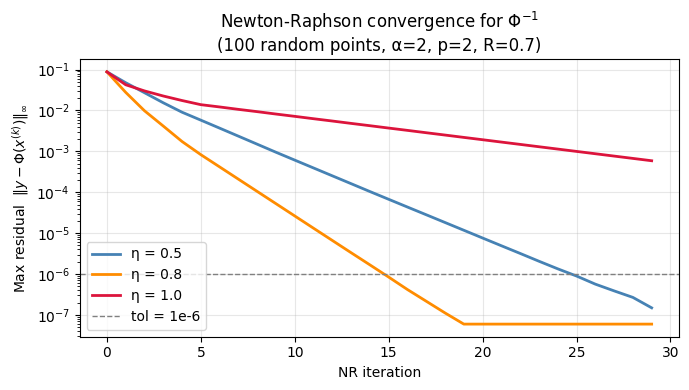

Iterations to reach 1e-6 with η=0.5: 25


In [46]:
def nr_convergence_profile(y, o, R, alpha=2.0, p=2.0, eta=0.5, max_iter=30):
    """Return per-iteration max residual for diagnostic purposes."""
    residuals = []
    with torch.no_grad():
        x = y.clone()
        for _ in range(max_iter):
            phi_x    = hyperbolic_foveated_transform(x, o, R, alpha, p)
            residual = y - phi_x
            residuals.append(residual.abs().max().item())
            x = (x + eta * residual).clamp(-1.5, 1.5)
    return residuals


torch.manual_seed(0)
o_cv = torch.tensor([0.05, -0.1])
R_cv = torch.tensor(0.7)
y_cv = (torch.rand(100, 2) * 2 - 1) * 0.8  # test points as "already-transformed"

fig, ax = plt.subplots(figsize=(7, 4))
for eta, color in [(0.5, 'steelblue'), (0.8, 'darkorange'), (1.0, 'crimson')]:
    profile = nr_convergence_profile(y_cv, o_cv, R_cv, eta=eta)
    ax.semilogy(profile, label=f'η = {eta}', color=color, linewidth=2)

ax.axhline(1e-6, color='gray', linestyle='--', linewidth=1, label='tol = 1e-6')
ax.set_xlabel('NR iteration')
ax.set_ylabel('Max residual  $\\|y - \\Phi(x^{(k)})\\|_\\infty$')
ax.set_title('Newton-Raphson convergence for $\\Phi^{-1}$\n(100 random points, α=2, p=2, R=0.7)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Report iterations needed to reach 1e-6 for default eta=0.5
profile_default = nr_convergence_profile(y_cv, o_cv, R_cv, eta=0.5, max_iter=50)
iters_needed = next((i for i, r in enumerate(profile_default) if r < 1e-6), 50)
print(f'Iterations to reach 1e-6 with η=0.5: {iters_needed}')

---
## 11 · Who decides *where* to point the lens? (a preview)

Everything so far assumed we already knew the centre $o$ and radius $R$ of the magnifying
glass. But the whole point of "*learnable* foveation" is that the network figures these out
by itself — it learns to aim the lens at wherever the distant, hard-to-see objects are.

That decision is made by a small neural network called the **FoveationEstimator** (a plain
3-layer MLP). It looks at a low-resolution thumbnail of the scene and outputs the four
numbers $[o_x, o_y, R_x, R_y]$. We define its interface here so the geometry engine has
something to connect to; we train it for real in the later notebooks.

```
★ Insight ─────────────────────────────────────
  • o is squashed through tanh so the centre always lands inside the
    image (the range -1…1), no matter what the network outputs.
  • R is pushed through softplus so the radius is always positive — a
    negative magnifying-glass size would be meaningless.
  • Using max(Rx, Ry) as a single radius keeps the lens circular and
    halves the number of knobs to learn (as the paper does).
─────────────────────────────────────────────────
```

**Coming up in NB 02:** we take this lens (Φ) and these parameters (o, R) and finally apply
them to a *real image* with PyTorch's `grid_sample`, turning the maths into actual pixels.

In [47]:
import torch.nn as nn


class FoveationEstimator(nn.Module):
    """Small FFN that predicts [o, R] from a flattened encoder feature vector.

    Paper: 3-layer MLP, input size 256 (from SAM3 1x feature map flattened),
    output [o_x, o_y, R_x, R_y]. We use R = max(R_x, R_y) as the paper does.

    This is a stub. The actual input dimension depends on the backbone.
    Replace `in_features` with the flattened encoder output size.
    """

    def __init__(self, in_features: int = 256, hidden: int = 256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 4),   # -> [o_x_logit, o_y_logit, R_x_logit, R_y_logit]
        )

    def forward(self, features: Tensor):
        """
        Args:
            features : (B, in_features) encoder feature vector
        Returns:
            o : (B, 2) foveation center in [-1, 1]^2
            R : (B,)   radial scale > 0
        """
        logits = self.mlp(features)                        # (B, 4)
        o = torch.tanh(logits[:, :2])                      # (B, 2) in (-1, 1)
        R_xy = torch.nn.functional.softplus(logits[:, 2:]) # (B, 2) > 0
        R = R_xy.max(dim=-1).values                        # (B,)  = max(Rx, Ry)
        return o, R


# ── Dimension check ──────────────────────────────────────────────────────────
est = FoveationEstimator(in_features=256)
dummy_feat = torch.randn(4, 256)   # batch of 4
o_pred, R_pred = est(dummy_feat)
print(f'o shape : {o_pred.shape}   range: [{o_pred.min():.3f}, {o_pred.max():.3f}]')
print(f'R shape : {R_pred.shape}   range: [{R_pred.min():.3f}, {R_pred.max():.3f}]')
assert o_pred.shape == (4, 2)
assert R_pred.shape == (4,)
assert (R_pred > 0).all(), 'R must be strictly positive'
print('PASS  FoveationEstimator shape check')



o shape : torch.Size([4, 2])   range: [-0.044, 0.111]
R shape : torch.Size([4])   range: [0.683, 0.737]
PASS  FoveationEstimator shape check


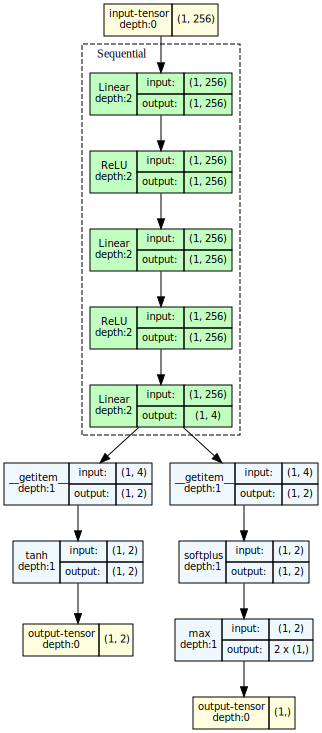

In [48]:
from torchview import draw_graph

# 1. Definimos el input dummy
dummy_input = torch.randn(1, 256)

# 2. La llamada correcta a draw_graph
model_graph = draw_graph(
    model=est, 
    input_data=dummy_input,
    # Parámetros de visualización (van aquí dentro)
    graph_name='Foveation_Scout_Network',
    expand_nested=True,
    show_shapes=True
)

# 3. Visualizar
model_graph.visual_graph